# CEU THESIS: 
The Effect O F

In [1]:
import pandas as pd
import numpy as np
import re
from unidecode import unidecode
import duckdb
import os
import math
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

import scipy.stats as stats
import pyarrow
from pandas.io.parquet import to_parquet
print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [2]:
cd = os.getcwd()
print(cd)
geo = cd+ '/geo'
agro= cd +"/Agromercados"
defens = cd +'/defensoria'
figures = cd + '/figures'
print("✅ Paths set successfully!")

/Users/amh/Desktop/CEU-EDP/THESIS/Data
✅ Paths set successfully!


In [3]:
# ── 0. PATHS ──────────────────────────────────────────────────────────────────
BASE = "/Users/amh/Desktop/CEU-EDP/THESIS/Data/defensoria"
RAW  = f"{BASE}/defensoria_raw.xlsx"
OUT  = f"{BASE}/defensoria_clean.parquet"   # parquet >> csv for >1M rows

## A. Defensoría data

In [4]:
# ── 1. CONNECTION & EXTENSIONS ────────────────────────────────────────────────
con = duckdb.connect(":memory:")
con.execute("INSTALL excel; LOAD excel;")
print("✅ DuckDB connected and Excel extension loaded!")

✅ DuckDB connected and Excel extension loaded!


### 1. Cleaning & Upload

In [5]:
# ── 2. LOAD + UNION ───────────────────────────────────────────────────────────
for tag, sheet in [("s1", "2022_2023"), ("s2", "2024_2026")]:
    con.execute(f"""
        CREATE TABLE raw_{tag} AS
        SELECT * FROM read_xlsx('{RAW}', sheet = '{sheet}')
    """)

con.execute("""
    CREATE OR REPLACE TABLE defensoria_raw AS
    SELECT * FROM raw_s1
    UNION ALL
    SELECT * FROM raw_s2
""")
print("✅ Data loaded and unioned successfully!")

✅ Data loaded and unioned successfully!


In [6]:
# ── 3. PANEL WINDOW + WEEK KEY ────────────────────────────────────────────────
# ISO week (Mon–Sun).  Swap '%G-W%V' → '%Y-W%U' if you prefer Sun-start.
PANEL_START = "2022-06-01"
PANEL_END   = "2025-12-31"

con.execute(f"""
    CREATE OR REPLACE TABLE defensoria_panel AS
    SELECT
        *,
        strftime("Fecha Sondeo", '%G-W%V')         AS iso_week,
        date_trunc('week', "Fecha Sondeo")          AS week_start,  -- Monday
        EXTRACT(year  FROM "Fecha Sondeo")::INT     AS yr,
        EXTRACT(month FROM "Fecha Sondeo")::INT     AS mo
    FROM defensoria_raw
    WHERE "Fecha Sondeo" BETWEEN DATE '{PANEL_START}' AND DATE '{PANEL_END}'
""")
print("✅ Panel window applied and week keys created!")

✅ Panel window applied and week keys created!


In [7]:
# ── 4. COMPACT QA SUMMARY (single pass) ───────────────────────────────────────
qa = con.execute("""
    SELECT
        COUNT(*)                         AS n_rows,
        COUNT(DISTINCT Distrito)         AS n_districts,
        COUNT(DISTINCT iso_week)         AS n_weeks,
        MIN("Fecha Sondeo")              AS date_min,
        MAX("Fecha Sondeo")              AS date_max
    FROM defensoria_panel
""").df()
print("=== QA SUMMARY ===")
print(qa.to_string(index=False))

=== QA SUMMARY ===
 n_rows  n_districts  n_weeks   date_min   date_max
1388314          189      186 2022-06-01 2025-12-30


In [8]:
# ── 5. DISTRICT × WEEK COVERAGE MATRIX ───────────────────────────────────────
coverage = con.execute("""
    SELECT
        Distrito,
        iso_week,
        COUNT(DISTINCT "Fecha Sondeo") AS n_obs
    FROM defensoria_panel
    GROUP BY Distrito, iso_week
""").df()

coverage_pivot = coverage.pivot_table(
    index="Distrito", columns="iso_week", values="n_obs", fill_value=0
)

total_weeks = coverage_pivot.shape[1]
coverage_pivot["pct_covered"] = (coverage_pivot > 0).sum(axis=1) / total_weeks * 100

print("\n=== DISTRICT COVERAGE (%) ===")
print(coverage_pivot[["pct_covered"]].sort_values("pct_covered").to_string())

thin_districts = coverage_pivot[coverage_pivot["pct_covered"] < 48].index.tolist()
print(f"\nDistricts below 50% coverage: {thin_districts}")

# ── 6. PRODUCT-LEVEL NULL DIAGNOSIS ──────────────────────────────────────────
meta_cols = {"Fecha Sondeo","Distrito","Mercado","iso_week","week_start","yr","mo"}
all_cols  = [c for c in con.execute("DESCRIBE defensoria_panel").df()["column_name"].tolist()
             if c not in meta_cols]

null_expr   = ",\n        ".join(
    [f'SUM(CASE WHEN "{c}" IS NULL THEN 1 ELSE 0 END) AS "{c}"' for c in all_cols]
)
null_counts = con.execute(f"SELECT {null_expr} FROM defensoria_panel").df().T.rename(columns={0:"n_null"})
n_total     = con.execute("SELECT COUNT(*) FROM defensoria_panel").fetchone()[0]
null_counts["pct_null"] = (null_counts["n_null"] / n_total * 100).round(2)

print("\n=== NULL RATE PER PRODUCT/COLUMN ===")
print(null_counts.sort_values("pct_null", ascending=False).to_string())


=== DISTRICT COVERAGE (%) ===
iso_week                   pct_covered
Distrito                              
Cuisnahuat                    0.537634
Sesori                        0.537634
La Reina                      0.537634
San Ildefonso                 0.537634
Candelaria                    0.537634
Concepción de Oriente         0.537634
Guaymango                     0.537634
Chiltiupán                    0.537634
Santa Isabel Ishuatán         0.537634
San Carlos                    0.537634
Santo Domingo de Guzmán       0.537634
Tenancingo                    0.537634
Tepetitán                     0.537634
San Agustín                   0.537634
Dolores                       0.537634
Nueva Esparta                 0.537634
Monte San Juan                0.537634
Ozatlán                       0.537634
Nuevo Cuscatlán               0.537634
Chirilagua                    0.537634
Santa Catarina Masahuat       0.537634
Masahuat                      0.537634
Concepción Batres             0.5

### 2. Calculating observation gaps:

In [9]:
# ── 7. GAP DIAGNOSIS (Calculated entirely in DuckDB) ─────────────────────────
print("\n=== CALCULATING OBSERVATION GAPS ===")

# Use SQL Window Functions (LAG) to find the days between consecutive observations 
# for the SAME product in the SAME district.
con.execute("""
    CREATE OR REPLACE VIEW defensoria_gaps AS
    WITH lagged AS (
        SELECT 
            Distrito, 
            Producto, 
            "Fecha Sondeo",
            LAG("Fecha Sondeo") OVER (
                PARTITION BY Distrito, Producto 
                ORDER BY "Fecha Sondeo"
            ) AS prev_obs_date
        FROM defensoria_panel
        WHERE Precio IS NOT NULL
    )
    SELECT 
        *,
        date_diff('day', prev_obs_date, "Fecha Sondeo") AS gap_days,
        (date_diff('day', prev_obs_date, "Fecha Sondeo") / 7) - 1 AS missing_weeks
    FROM lagged
    WHERE prev_obs_date IS NOT NULL
""")

# ── 8. BI-WEEKLY (14-DAY) AGGREGATION & COVERAGE SURVIVAL CHECK ──────────────
print("\n=== GENERATING BI-WEEKLY PANEL ===")

# Use DuckDB's time_bucket to group exactly by 14-day intervals
con.execute("""
    CREATE OR REPLACE TABLE defensoria_biweekly AS
    SELECT 
        Distrito, 
        Producto, 
        time_bucket(INTERVAL '14 Days', week_start) AS period_14d,
        AVG(Precio) AS precio_mean,
        COUNT(Precio) AS n_obs
    FROM defensoria_panel
    WHERE Precio IS NOT NULL
    GROUP BY Distrito, Producto, period_14d
""")

n_biweekly_obs = con.execute("SELECT COUNT(*) AS n_biweekly_obs FROM defensoria_biweekly").fetchone()[0]
print(f"✅ Bi-weekly panel generated. Total observations: {n_biweekly_obs}")

# Calculate the new coverage percentage based on the bi-weekly panel
coverage_14d = con.execute("""
    WITH totals AS (
        SELECT COUNT(DISTINCT period_14d) as max_periods FROM defensoria_biweekly
    )
    SELECT 
        d.Distrito,
        COUNT(DISTINCT d.period_14d) AS periods_covered,
        ROUND((COUNT(DISTINCT d.period_14d) * 100.0 / t.max_periods), 2) AS pct_covered
    FROM defensoria_biweekly d
    CROSS JOIN totals t
    GROUP BY d.Distrito, t.max_periods
    ORDER BY pct_covered ASC
""").df()

print("\n=== NEW BI-WEEKLY (14-DAY) COVERAGE (%) ===")
print(coverage_14d.tail(50).to_string(index=False))

# Survival Check
survivors = coverage_14d[coverage_14d['pct_covered'] >= 40.0]
print(f"\n✅ Districts surviving >40% coverage threshold: {len(survivors)} out of {len(coverage_14d)}")


=== CALCULATING OBSERVATION GAPS ===

=== GENERATING BI-WEEKLY PANEL ===
✅ Bi-weekly panel generated. Total observations: 205493

=== NEW BI-WEEKLY (14-DAY) COVERAGE (%) ===
                 Distrito  periods_covered  pct_covered
                    Turín               34        35.79
                  Jucuapa               34        35.79
                   Juayúa               35        36.84
        Antiguo Cuscatlán               36        37.89
               San Martín               36        37.89
              La Libertad               37        38.95
                 Acajutla               37        38.95
                Sonzacate               38        40.00
      Concepción de Ataco               38        40.00
        San Rafael Cedros               38        40.00
                 Ilopango               39        41.05
            San Sebastián               39        41.05
Candelaria de la Frontera               39        41.05
        Santiago de María               4

### 3. heatmaps for missing data across district markets

print("\n=== GENERATING BATCHED MISSINGNESS HEATMAPS ===")

 ── 1. PULL AND PIVOT THE DATA ───────────────────────────────────────────────
heatmap_df = con.execute("""
    SELECT 
        Distrito, 
        iso_week, 
        CASE WHEN COUNT(Precio) > 0 THEN 1 ELSE 0 END AS is_observed
    FROM defensoria_panel
    GROUP BY Distrito, iso_week
""").df()

 Pivot: Rows = Districts, Columns = Weeks
pivot_heatmap = heatmap_df.pivot(index='Distrito', columns='iso_week', values='is_observed').fillna(0)

 Calculate total coverage to sort (Descending: Best coverage first)
pivot_heatmap['total_obs'] = pivot_heatmap.sum(axis=1)
pivot_heatmap = pivot_heatmap.sort_values('total_obs', ascending=False)
pivot_heatmap = pivot_heatmap.drop(columns=['total_obs'])

 ── 2. LOOP AND GENERATE BATCHES OF 25 ───────────────────────────────────────
BATCH_SIZE = 25
total_districts = len(pivot_heatmap)
num_batches = math.ceil(total_districts / BATCH_SIZE)

for i in range(num_batches):
    start_idx = i * BATCH_SIZE
    end_idx = min((i + 1) * BATCH_SIZE, total_districts)
    
    # Slice the dataframe for the current batch
    batch_data = pivot_heatmap.iloc[start_idx:end_idx]
    
    # Plotting
    plt.figure(figsize=(14, 8)) # Optimal dimensions for 25 rows on A4 paper
    sns.heatmap(
        batch_data, 
        cmap=['#e74c3c', '#2ecc71'], # Red for missing (0), Green for observed (1)
        cbar=False, 
        yticklabels=True, 
        xticklabels=5 # Show every 5th week to avoid X-axis text overlap
    )
    
    plt.title(f'Panel Missingness Matrix: Batch {i+1} of {num_batches}\n(Districts Rank {start_idx+1} to {end_idx} by Coverage)', fontsize=15, pad=15)
    plt.xlabel('ISO Week', fontsize=12)
    plt.ylabel('District', fontsize=12)
    
    plt.tight_layout()
    
    # Save dynamically
    filename = (figures + "/district_missingness_heatmap_batch_" + str(i+1) + ".png")
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.close() # CRITICAL: Close the figure to free up RAM before the next loop
    
    print(f"✅ Saved: district_missingness_heatmap_batch_{i+1}.png (Rows {start_idx+1}-{end_idx})")

print(f"\nSuccessfully generated {num_batches} heatmap panels.")

### 4. Final panel, dropping all markets with <50% coverage

In [10]:
# ── 9. CREACIÓN DEL PANEL FINAL ─────────────────────────────────
print("\n=== Filtering final panel (Preserving >= 49.0% BI-WEEKLY COVERAGE) ===")

con.execute("""
    CREATE OR REPLACE TABLE defensoria_clean AS
    WITH valid_districts AS (
        WITH totals AS (
            SELECT COUNT(DISTINCT period_14d) as max_periods FROM defensoria_biweekly
        )
        SELECT 
            d.Distrito
        FROM defensoria_biweekly d
        CROSS JOIN totals t
        GROUP BY d.Distrito, t.max_periods
        HAVING (COUNT(DISTINCT d.period_14d) * 100.0 / t.max_periods) >= 49.0
    )
    SELECT p.*
    FROM defensoria_panel p
    INNER JOIN valid_districts vd ON p.Distrito = vd.Distrito
""")

df_defensoria_clean = con.execute("SELECT * FROM defensoria_clean").df()

final_rows = con.execute("SELECT COUNT(*) FROM defensoria_clean").fetchone()[0]
print(f"✅ Final panel consolidated. Total of retained observations: {final_rows}")


=== Filtering final panel (Preserving >= 49.0% BI-WEEKLY COVERAGE) ===
✅ Final panel consolidated. Total of retained observations: 999071


In [11]:
### save unique districts to list for later use in geospatial merging
districts_list = con.execute("SELECT DISTINCT Distrito FROM defensoria_clean").df()
districts_list.to_csv(f"{BASE}/final_districts_list.csv", index=False)
print("✅ Unique districts saved to final_districts_list.csv for geospatial merging.")

✅ Unique districts saved to final_districts_list.csv for geospatial merging.


## Product Name Cleaning

In [12]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 9b: PRODUCT HARMONISATION — policy-anchored, single-pass
# Anchor: 14 official Agromercado launch products (July 2024)
# Logic:  map Defensoría raw names → basket family → drop everything else
# Output: defensoria_clean_prod  (canonical_product column added)
# ══════════════════════════════════════════════════════════════════════════════
DEFENSORIA_FAMILY_MAP = {
    # ── TOMATE ──────────────────────────────────────────────────────────────
    "Tomate de cocina":              "Tomate",
    "Tomate de cocina grande":       "Tomate",
    "Tomate de cocina pequeño":      "Tomate",
    "Tomate de ensalada":            "Tomate",
    "Tomate de ensalada grande":     "Tomate",
    "Tomate de ensalada pequeño":    "Tomate",
    # ── CEBOLLA BLANCA ──────────────────────────────────────────────────────
    "Cebolla, blanca":               "Cebolla blanca",
    "Cebolla, Blanca grande":        "Cebolla blanca",
    "Cebolla, Blanca pequeña":       "Cebolla blanca",
    # ── CEBOLLA MORADA ──────────────────────────────────────────────────────
    "Cebolla, morada":               "Cebolla morada",
    "Cebolla, morada grande":        "Cebolla morada",
    "Cebolla, morada pequeña":       "Cebolla morada",
    # ── CEBOLLA AMARILLA ────────────────────────────────────────────────────
    "Cebolla, amarilla":             "Cebolla amarilla",
    "Cebolla, amarilla grande":      "Cebolla amarilla",
    "Cebolla, amarilla pequeña":     "Cebolla amarilla",
    # ── REPOLLO ─────────────────────────────────────────────────────────────
    "Repollo verde":                 "Repollo",
    "Repollo, Verde grande":         "Repollo",
    "Repollo, Verde pequeño":        "Repollo",
    # ── PAPA ────────────────────────────────────────────────────────────────
    "Papa":                          "Papa",
    "Papa lavada":                   "Papa",
    "Papa morena":                   "Papa",
    # ── LECHUGA ─────────────────────────────────────────────────────────────
    "Lechuga repollada":             "Lechuga",
    "Lechuga repollada (unidad)":    "Lechuga",
    "Lechuga repollada grande":      "Lechuga",
    "Lechuga repollada pequeña":     "Lechuga",
    # ── ZANAHORIA ───────────────────────────────────────────────────────────
    "Zanahoria":                     "Zanahoria",
    "Zanahoria (unidad)":            "Zanahoria",
    "Zanahoria grande":              "Zanahoria",
    "Zanahoria pequeña":             "Zanahoria",
    # ── BRÓCOLI ─────────────────────────────────────────────────────────────
    "Brócoli":                       "Brócoli",
    "Brócoli (unidad)":              "Brócoli",
    "Brócoli pequeño":               "Brócoli",
    "Brócoli grande":                "Brócoli",
    # ── PEPINO (Lisboa → Pepino criollo family) ──────────────────────────────
    "Pepino criollo":                "Pepino",
    "Pepino criollo grande":         "Pepino",
    "Pepino criollo pequeño":        "Pepino",
    # ── CHILE VERDE ─────────────────────────────────────────────────────────
    "Chile verde":                   "Chile verde",
    "Chile verde grande":            "Chile verde",
    "Chile verde pequeño":           "Chile verde",
    # ── GÜISQUIL ────────────────────────────────────────────────────────────
    "Güisquil criollo":              "Güisquil",
    "Güisquil, Criollo grande":      "Güisquil",
    "Güisquil, Criollo pequeño":     "Güisquil",
    "Güisquil oscuro":               "Güisquil",
    "Güisquil, Oscuro grande":       "Güisquil",
    "Güisquil, Oscuro pequeño":      "Güisquil",
    "Güisquil Blanco":               "Güisquil",
    "Güisquil, Blanco grande":       "Güisquil",
    "Güisquil, Blanco pequeño":      "Güisquil",
    "Guisquil oscuro / negro":       "Güisquil",
    "Guisquil oscuro / negro grande":"Güisquil",
    "Guisquil oscuro / negro pequeño":"Güisquil",
}


In [13]:
MYBASKET = sorted(set(DEFENSORIA_FAMILY_MAP.values()))
print(f"Basket families: {len(MYBASKET)}")

Basket families: 12


In [14]:
# ── 2. Apply map and drop unmapped rows ──────────────────────────────────────
df = con.execute("SELECT * FROM defensoria_clean").df()
print(f"Rows before: {len(df):,}")

df["canonical_product"] = df["Producto"].map(DEFENSORIA_FAMILY_MAP)

# Audit: unmapped must only be intentional non-basket products
n_unmapped = df["canonical_product"].isna().sum()
print(f"Unmapped rows (dropped): {n_unmapped:,}")
if n_unmapped > 0:
    print(df[df["canonical_product"].isna()]["Producto"].value_counts().head(20).to_string())

df_clean = (
    df[df["canonical_product"].notna()]
    .drop(columns="Producto")
    .reset_index(drop=True)
)
print(f"Rows after:  {len(df_clean):,}")
print(f"Canonical families: {df_clean['canonical_product'].nunique()}")
print(sorted(df_clean['canonical_product'].unique()))

# ── 3. Register in DuckDB ─────────────────────────────────────────────────────
con.register("defensoria_clean_prod_df", df_clean)
con.execute("""
    CREATE OR REPLACE TABLE defensoria_clean_prod
    AS SELECT * FROM defensoria_clean_prod_df
""")
print("✅ defensoria_clean_prod ready.")

Rows before: 999,071
Unmapped rows (dropped): 648,231
Producto
Frijol rojo de seda (minorista)    27616
Arroz blanco (minorista)           26239
Arroz precocido (minorista)        24405
Huevo grande                       22156
Plátano corriente                  20350
Ajo                                19892
Aguacate Hass                      18646
Guineo de seda                     16676
Papaya, Tainung (unidad)           16040
Huevo mediano                      16037
Maíz blanco (minorista)            15373
Piña, Hawaiana (unidad)            14988
Pipián                             14654
Coliflor                           14468
Harina de Trigo Suave              14321
Remolacha, Cruda                   14019
Maicillo (minorista)               14014
Maíz blanco (mayorista)            13291
Harina de Trigo Fuerte             12768
Sandia, Redonda (unidad)           12588
Rows after:  350,840
Canonical families: 12
['Brócoli', 'Cebolla amarilla', 'Cebolla blanca', 'Cebolla morada', 'Chil

## C. Track 1 & 2 DF Construction
Forward filling weekly for C&S DID, no inputation for CV

### 1. Create df_treated

In [15]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 10: MERGE TREATMENT ASSIGNMENT
# ══════════════════════════════════════════════════════════════════════════════
norm = lambda x: unidecode(str(x)).lower().strip()

treat = pd.read_csv(geo + '/treatment_assignment_43.csv')
treat['apertura_date'] = pd.to_datetime(treat['apertura_date'])
treat['market_key']    = treat['market_district'].apply(norm)
df_clean['market_key'] = df_clean['Distrito'].apply(norm)

df_treated = df_clean.merge(
    treat[['market_key', 'distance_km', 'closest_agro',
           'treated_5km', 'treated_10km', 'treated_15km',
           'first_treated_week', 'apertura_date']],
    on='market_key', how='inner'
)

matched   = df_treated['Distrito'].nunique()
unmatched = df_clean[~df_clean['market_key'].isin(treat['market_key'])]['Distrito'].unique()
print(f"✅ Districts matched: {matched}")
if len(unmatched):
    print(f"⚠️  Unmatched (dropped): {sorted(unmatched)}")

con.register('df_treated', df_treated)
con.execute("CREATE OR REPLACE TABLE defensoria_treated AS SELECT * FROM df_treated")
print(f"✅ defensoria_treated ready. Rows: {len(df_treated):,}")

✅ Districts matched: 32
✅ defensoria_treated ready. Rows: 350,840


In [16]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 11: OUTCOME VARIABLES
# Unit: (Distrito, canonical_product, period_14d)
# ══════════════════════════════════════════════════════════════════════════════
con.execute("""
CREATE OR REPLACE TABLE panel_outcomes AS
SELECT
    Distrito, canonical_product,
    time_bucket(INTERVAL '14 Days', week_start) AS period_14d,
    treated_5km, treated_10km, treated_15km,
    first_treated_week, apertura_date,
    distance_km, closest_agro,
    COUNT(Precio)                                        AS n_obs,
    AVG(Precio)                                          AS price_mean,
    STDDEV_SAMP(Precio)                                  AS price_sd,
    CASE WHEN COUNT(Precio) >= 2 AND AVG(Precio) > 0
         THEN STDDEV_SAMP(Precio) / AVG(Precio) END      AS price_cv,
    LN(NULLIF(AVG(Precio), 0))                           AS log_price_mean,
    MIN(Precio)                                          AS price_min,
    MAX(Precio)                                          AS price_max
FROM defensoria_treated
WHERE Precio IS NOT NULL AND Precio > 0
GROUP BY Distrito, canonical_product, period_14d,
         treated_5km, treated_10km, treated_15km,
         first_treated_week, apertura_date, distance_km, closest_agro
""")

print(con.execute("""
    SELECT COUNT(*)                          AS n_rows,
           COUNT(DISTINCT Distrito)          AS n_markets,
           COUNT(DISTINCT canonical_product) AS n_products,
           COUNT(DISTINCT period_14d)        AS n_periods,
           ROUND(AVG(price_cv),   4)         AS mean_cv,
           ROUND(AVG(price_mean), 4)         AS mean_price,
           SUM(CASE WHEN price_cv IS NULL THEN 1 ELSE 0 END) AS n_null_cv
    FROM panel_outcomes
""").df())

print(con.execute("""
    SELECT canonical_product,
           COUNT(*) AS n_rows,
           SUM(CASE WHEN price_cv IS NULL THEN 1 ELSE 0 END) AS n_null_cv,
           ROUND(SUM(CASE WHEN price_cv IS NULL THEN 1 ELSE 0 END)
                 * 100.0 / COUNT(*), 1) AS pct_null_cv
    FROM panel_outcomes
    GROUP BY canonical_product
    ORDER BY pct_null_cv DESC
""").df())

   n_rows  n_markets  n_products  n_periods  mean_cv  mean_price  n_null_cv
0   23470         32          12         95   0.2632       0.917      462.0
   canonical_product  n_rows  n_null_cv  pct_null_cv
0   Cebolla amarilla     746      137.0         18.4
1            Brócoli    2137       53.0          2.5
2           Güisquil    2135       46.0          2.2
3     Cebolla morada    2150       42.0          2.0
4            Repollo    2128       41.0          1.9
5             Pepino    1239       23.0          1.9
6               Papa    2143       38.0          1.8
7        Chile verde    2162       23.0          1.1
8            Lechuga    2143       23.0          1.1
9          Zanahoria    2155       15.0          0.7
10    Cebolla blanca    2169       13.0          0.6
11            Tomate    2163        8.0          0.4


### 2. Create basket of products

In [17]:

# ══════════════════════════════════════════════════════════════════════════════
# STEP 12: PANEL AUDIT
# ══════════════════════════════════════════════════════════════════════════════
print(con.execute("""
    SELECT treated_5km,
           COUNT(DISTINCT Distrito)          AS n_markets,
           COUNT(DISTINCT canonical_product) AS n_products,
           COUNT(*)                          AS n_rows
    FROM defensoria_treated GROUP BY treated_5km
""").df())

print(con.execute("""
    SELECT first_treated_week,
           COUNT(DISTINCT Distrito) AS n_markets,
           MIN(week_start) AS panel_start, MAX(week_start) AS panel_end,
           COUNT(DISTINCT CASE WHEN week_start < apertura_date THEN iso_week END) AS pre_weeks
    FROM defensoria_treated WHERE treated_5km = 1
    GROUP BY first_treated_week ORDER BY first_treated_week
""").df())

print(con.execute("""
    SELECT treated_5km,
           MIN(n_products) AS min, ROUND(AVG(n_products),1) AS avg, MAX(n_products) AS max
    FROM (SELECT Distrito, treated_5km,
                 COUNT(DISTINCT canonical_product) AS n_products
          FROM defensoria_treated GROUP BY Distrito, treated_5km)
    GROUP BY treated_5km
""").df())

print(con.execute("""
    SELECT Distrito, MIN(week_start) AS first_obs, MAX(week_start) AS last_obs,
           COUNT(DISTINCT iso_week) AS n_weeks
    FROM defensoria_treated WHERE treated_5km = 0
    GROUP BY Distrito ORDER BY n_weeks DESC
""").df())



   treated_5km  n_markets  n_products  n_rows
0            0          6          12   77562
1            1         26          12  273278
  first_treated_week  n_markets panel_start  panel_end  pre_weeks
0           2024-W28          8  2022-05-30 2025-12-29        108
1           2024-W30          2  2022-05-30 2025-12-29         94
2           2024-W31          4  2022-05-30 2025-12-22        111
3           2024-W33          2  2022-06-06 2025-12-15         96
4           2024-W34          4  2022-05-30 2025-12-29         96
5           2024-W38          2  2022-05-30 2025-12-22         81
6           2024-W45          2  2022-06-06 2025-12-22         76
7           2025-W07          1  2022-05-30 2025-12-22        119
8           2025-W21          1  2022-09-12 2025-12-08         70
   treated_5km  min   avg  max
0            0   12  12.0   12
1            1   12  12.0   12
                   Distrito  first_obs   last_obs  n_weeks
0                San Miguel 2022-05-30 2025-12-15 

In [18]:

# CHECK 3: Product coverage per market
print("\n── CHECK 3: Canonical products per market (treated vs control) ──")
print(con.execute("""
    SELECT treated_5km,
           MIN(n_products) AS min,
           ROUND(AVG(n_products),1) AS avg,
           MAX(n_products) AS max
    FROM (
        SELECT Distrito, treated_5km,
               COUNT(DISTINCT canonical_product) AS n_products
        FROM defensoria_treated
        GROUP BY Distrito, treated_5km
    )
    GROUP BY treated_5km
""").df())

# CHECK 4: Never-treated temporal coverage
print("\n── CHECK 4: Never-treated market observation span ──")
print(con.execute("""
    SELECT Distrito,
           MIN(week_start) AS first_obs,
           MAX(week_start) AS last_obs,
           COUNT(DISTINCT iso_week) AS n_weeks
    FROM defensoria_treated
    WHERE treated_5km = 0
    GROUP BY Distrito
    ORDER BY n_weeks DESC
""").df())


── CHECK 3: Canonical products per market (treated vs control) ──
   treated_5km  min   avg  max
0            0   12  12.0   12
1            1   12  12.0   12

── CHECK 4: Never-treated market observation span ──
                   Distrito  first_obs   last_obs  n_weeks
0                San Miguel 2022-05-30 2025-12-15      165
1                  La Unión 2022-05-30 2025-12-29      134
2               San Vicente 2022-05-30 2025-12-01       98
3               Chapeltique 2022-05-30 2025-12-22       80
4              Texistepeque 2022-06-06 2025-12-08       74
5  San Sebastián Salitrillo 2022-09-05 2025-12-22       63


## D. TRACK 1 & 2 PANELS

### D.1 . TRACK 1–PANEL

In [19]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 13A: TRACK 1 PANEL — product-level bi-weekly log price
# ══════════════════════════════════════════════════════════════════════════════
con.execute("""
CREATE OR REPLACE TABLE panel_track1 AS
SELECT * FROM panel_outcomes WHERE log_price_mean IS NOT NULL
""")

print(con.execute("""
    SELECT COUNT(*) AS n_rows, COUNT(DISTINCT Distrito) AS n_districts,
           COUNT(DISTINCT canonical_product) AS n_products,
           COUNT(DISTINCT period_14d) AS n_periods,
           MIN(period_14d) AS first_period, MAX(period_14d) AS last_period
    FROM panel_track1
""").df())
print("✅ Track 1 panel ready.")


   n_rows  n_districts  n_products  n_periods first_period last_period
0   23470           32          12         95   2022-05-23  2025-12-29
✅ Track 1 panel ready.


### D.2 TRACK 2– PANEL

In [20]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 13B: TRACK 2 PANEL — district-level basket CV
# ══════════════════════════════════════════════════════════════════════════════
con.execute(f"""
CREATE OR REPLACE TABLE panel_track2 AS
SELECT Distrito, period_14d,
       AVG(price_cv)              AS basket_cv,
       COUNT(canonical_product)   AS nproducts_validcv,
       {len(MYBASKET)} - COUNT(canonical_product) AS nproducts_missingcv
FROM panel_outcomes
WHERE price_cv IS NOT NULL
GROUP BY Distrito, period_14d
""")

print(con.execute("""
    SELECT COUNT(*) AS n_rows, COUNT(DISTINCT Distrito) AS n_districts,
           COUNT(DISTINCT period_14d) AS n_periods,
           ROUND(AVG(basket_cv), 4) AS mean_basket_cv
    FROM panel_track2
""").df())
print("✅ Track 2 panel ready.")


   n_rows  n_districts  n_periods  mean_basket_cv
0    2183           32         95          0.2588
✅ Track 2 panel ready.


## DID Input

In [21]:
from csdid.att_gt import ATTgt
print("✅ csdid imported successfully")

✅ csdid imported successfully


In [22]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 14: DiD INPUT CONSTRUCTION (both tracks)
# ══════════════════════════════════════════════════════════════════════════════

# Treatment timing lookup — one row per district
treat_timing = (
    df_treated[['Distrito', 'market_key', 'treated_5km', 'first_treated_week', 'apertura_date']]
    .drop_duplicates(subset='market_key').copy()
)
treat_timing['apertura_date'] = pd.to_datetime(treat_timing['apertura_date'])

def assign_G(row, min_period):
    if row['treated_5km'] == 0 or pd.isna(row['apertura_date']):
        return 0
    g_val = int((pd.to_datetime(row['apertura_date']) - pd.to_datetime(min_period)).days // 14)
    return max(1, g_val)

# ── Track 1 ───────────────────────────────────────────────────────────────────
df_t1 = con.execute("SELECT * FROM panel_track1").df()
df_t1 = df_t1.drop(columns=[c for c in ['apertura_date','treated_5km'] if c in df_t1.columns])
df_t1['market_key'] = df_t1['Distrito'].apply(norm)
df_t1 = df_t1.merge(treat_timing[['market_key','treated_5km','apertura_date']],
                    on='market_key', how='left')
df_t1['treated_5km'] = df_t1['treated_5km'].fillna(0).astype(int)
df_t1['period_14d']  = pd.to_datetime(df_t1['period_14d'])

min_t1 = df_t1['period_14d'].min()
df_t1['timeid']    = ((df_t1['period_14d'] - min_t1).dt.days // 14).astype(int)
df_t1['unit_name'] = df_t1['Distrito'] + '_' + df_t1['canonical_product']
df_t1['unitid']    = df_t1['unit_name'].map(
    {u: i for i, u in enumerate(sorted(df_t1['unit_name'].unique()))})
df_t1['G']         = df_t1.apply(assign_G, axis=1, min_period=min_t1)

df_t1_did = df_t1[['unitid','unit_name','Distrito','canonical_product',
                    'period_14d','timeid','G','treated_5km','log_price_mean','n_obs']].copy()

print(f"✅ Track 1 DiD input | Rows: {len(df_t1_did):,} | Units: {df_t1_did['unitid'].nunique()} | Periods: {df_t1_did['timeid'].nunique()}")
print(f"   G values: {sorted(df_t1_did['G'].unique())}")
print(f"   Never-treated (G=0): {sorted(df_t1_did[df_t1_did['G']==0]['Distrito'].unique())}")

# ── Track 2 ───────────────────────────────────────────────────────────────────
df_t2 = con.execute("SELECT * FROM panel_track2").df()
df_t2['market_key']  = df_t2['Distrito'].apply(norm)
df_t2['period_14d']  = pd.to_datetime(df_t2['period_14d'])
df_t2 = df_t2.merge(treat_timing[['market_key','treated_5km','apertura_date']],
                    on='market_key', how='left')
df_t2['treated_5km'] = df_t2['treated_5km'].fillna(0).astype(int)

min_t2 = df_t2['period_14d'].min()
df_t2['timeid'] = ((df_t2['period_14d'] - min_t2).dt.days // 14).astype(int)
df_t2['unitid'] = df_t2['Distrito'].map(
    {u: i for i, u in enumerate(sorted(df_t2['Distrito'].unique()))})
df_t2['G']      = df_t2.apply(assign_G, axis=1, min_period=min_t2)

print(f"✅ Track 2 DiD input | Rows: {len(df_t2):,} | Districts: {df_t2['unitid'].nunique()} | Periods: {df_t2['timeid'].nunique()}")
print(f"   G values: {sorted(df_t2['G'].unique())}")
print(f"   Never-treated (G=0): {sorted(df_t2[df_t2['G']==0]['Distrito'].unique())}")


✅ Track 1 DiD input | Rows: 23,470 | Units: 384 | Periods: 95
   G values: [0, 55, 56, 57, 58, 60, 64, 71, 78]
   Never-treated (G=0): ['Chapeltique', 'La Unión', 'San Miguel', 'San Sebastián Salitrillo', 'San Vicente', 'Texistepeque']
✅ Track 2 DiD input | Rows: 2,183 | Districts: 32 | Periods: 95
   G values: [0, 55, 56, 57, 58, 60, 64, 71, 78]
   Never-treated (G=0): ['Chapeltique', 'La Unión', 'San Miguel', 'San Sebastián Salitrillo', 'San Vicente', 'Texistepeque']


In [23]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 15: HELPER FUNCTIONS
# ══════════════════════════════════════════════════════════════════════════════
from scipy import stats
from csdid.att_gt import ATTgt

def extract_es(atte, label):
    df = pd.DataFrame({
        'event_time': np.array(atte['egt']).flatten(),
        'att':        np.array(atte['att_egt']).flatten().astype(float),
        'se':         np.array(atte['se_egt']).flatten().astype(float),
    })
    df['ci_lower'] = df['att'] - 1.96 * df['se']
    df['ci_upper'] = df['att'] + 1.96 * df['se']
    df['pval'] = df.apply(
        lambda r: np.nan if r['se'] == 0 or pd.isna(r['se'])
                  else 2 * (1 - stats.norm.cdf(abs(r['att'] / r['se']))), axis=1)
    df['sig']   = df['pval'].apply(
        lambda p: '' if pd.isna(p) else
                  '***' if p<0.01 else '**' if p<0.05 else '*' if p<0.1 else '')
    df['track'] = label
    return df

def print_prepost(es_df, pre=(-50,-1), post=(0,20)):
    pre_df  = es_df[es_df['event_time'].between(*pre)]
    post_df = es_df[es_df['event_time'].between(*post)]
    print(f"PRE ({pre[0]} to {pre[1]}):  mean ATT={pre_df['att'].mean():.4f} | "
          f"any sig (p<.10): {(pre_df['pval']<0.10).any()}")
    print(f"POST ({post[0]} to {post[1]}): mean ATT={post_df['att'].mean():.4f} | "
          f"n sig (p<.05): {(post_df['pval']<0.05).sum()}")

print("✅ Helper functions ready.")


✅ Helper functions ready.


### Track 1. Estimation

In [24]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 16A: ESTIMATION — TRACK 1 (log price mean)
# ══════════════════════════════════════════════════════════════════════════════
df_t1_est = df_t1_did.dropna(subset=['log_price_mean']).copy()
df_t1_est['district_id'] = df_t1_est['Distrito'].astype('category').cat.codes

# ── Cohort size audit — drop thin cohorts ─────────────────────────────────────
cohort_sizes = df_t1_est.groupby('G')['unitid'].nunique().sort_values()
print("Cohort sizes (composite units per G):")
print(cohort_sizes.to_string())
MIN_UNITS = 5
valid_G   = cohort_sizes[cohort_sizes >= MIN_UNITS].index.tolist()
df_t1_est = df_t1_est[df_t1_est['G'].isin(valid_G + [0])].copy()
print(f"Retained G values (>={MIN_UNITS} units): {sorted(valid_G)}")
print(f"Rows after trim: {len(df_t1_est):,}")

cs_t1 = ATTgt(
    yname         = 'log_price_mean',
    tname         = 'timeid',
    idname        = 'unitid',
    gname         = 'G',
    data          = df_t1_est,
    control_group = 'notyettreated',
    anticipation  = 0,
    clustervar    = 'district_id'
)
cs_t1.fit(est_method='dr')
print("✅ Track 1 fit complete.")

# ── aggte('simple') FIRST — populates atte, save scalars immediately ──────────
cs_t1.aggte(typec='simple', na_rm=True)
overall_att_t1 = float(np.array(cs_t1.atte['overall_att']).flatten()[0])
overall_se_t1  = float(np.array(cs_t1.atte['overall_se']).flatten()[0])
print(f"Overall ATT: {overall_att_t1:.4f}  SE: {overall_se_t1:.4f}  "
      f"p={2*(1-stats.norm.cdf(abs(overall_att_t1/overall_se_t1))):.3f}")

# ── aggte('dynamic') SECOND — overwrites atte, extract immediately ────────────
cs_t1.aggte(typec='dynamic', na_rm=True)
es_t1_df = extract_es(cs_t1.atte, 'track1_log_price')
es_t1_df.to_csv(f"{BASE}/es_track1_log_price_notyettreated.csv", index=False)
print_prepost(es_t1_df)



Cohort sizes (composite units per G):
G
71    12
78    12
56    24
60    24
64    24
57    48
0     72
58    72
55    96
Retained G values (>=5 units): [0, 55, 56, 57, 58, 60, 64, 71, 78]
Rows after trim: 23,470
No units in group 56 in time period 19, e1
No units in group 56 in time period 19, e2
No units in group 56 in time period 53, e1
No units in group 56 in time period 53, e2
No units in group 56 in time period 76, e1
No units in group 56 in time period 86, e1
No units in group 56 in time period 87, e1
No units in group 57 in time period 95, e1
No units in group 58 in time period 76, e1
No units in group 60 in time period 16, e1
No units in group 60 in time period 16, e2
No units in group 60 in time period 19, e1
No units in group 60 in time period 19, e2
No units in group 60 in time period 31, e1
No units in group 60 in time period 31, e2
No units in group 60 in time period 41, e1
No units in group 60 in time period 41, e2
No units in group 60 in time period 43, e1
No units in gr

### Track 2. Estimation

In [25]:

# ══════════════════════════════════════════════════════════════════════════════
# STEP 16B: ESTIMATION — TRACK 2 (basket CV)
# ══════════════════════════════════════════════════════════════════════════════
df_t2_est = df_t2.dropna(subset=['basket_cv']).copy()
df_t2_est['district_id'] = df_t2_est['Distrito'].astype('category').cat.codes

cs_t2 = ATTgt(
    yname                  = 'basket_cv',
    tname                  = 'timeid',
    idname                 = 'unitid',
    gname                  = 'G',
    data                   = df_t2_est,
    control_group          = 'notyettreated',
    anticipation           = 0,
    allow_unbalanced_panel = True,
    clustervar             = 'district_id'
)
cs_t2.fit(est_method='dr')
print("✅ Track 2 fit complete.")

# ── Same pattern: simple first, dynamic second ────────────────────────────────
cs_t2.aggte(typec='simple', na_rm=True)
overall_att_t2 = float(np.array(cs_t2.atte['overall_att']).flatten()[0])
overall_se_t2  = float(np.array(cs_t2.atte['overall_se']).flatten()[0])
print(f"Overall ATT: {overall_att_t2:.4f}  SE: {overall_se_t2:.4f}  "
      f"p={2*(1-stats.norm.cdf(abs(overall_att_t2/overall_se_t2))):.3f}")

cs_t2.aggte(typec='dynamic', na_rm=True)
es_t2_df = extract_es(cs_t2.atte, 'track2_basket_cv')
es_t2_df.to_csv(f"{BASE}/es_track2_basket_cv_notyettreated.csv", index=False)
print_prepost(es_t2_df)

No units in group 56 in time period 19, e1
No units in group 56 in time period 19, e2
No units in group 56 in time period 53, e1
No units in group 56 in time period 53, e2
No units in group 56 in time period 76, e1
No units in group 56 in time period 86, e1
No units in group 56 in time period 87, e1
No units in group 57 in time period 95, e1
No units in group 58 in time period 76, e1
No units in group 60 in time period 16, e1
No units in group 60 in time period 16, e2
No units in group 60 in time period 19, e1
No units in group 60 in time period 19, e2
No units in group 60 in time period 31, e1
No units in group 60 in time period 31, e2
No units in group 60 in time period 41, e1
No units in group 60 in time period 41, e2
No units in group 60 in time period 43, e1
No units in group 60 in time period 43, e2
No units in group 60 in time period 48, e1
No units in group 60 in time period 48, e2
No units in group 60 in time period 50, e1
No units in group 60 in time period 50, e2
No units in

## Resuts:

In [26]:
def make_summary_table(label, overall_att, overall_se, es_df, pre_window=(-50,-1), post_window=(0,20)):
    pval = 2 * (1 - stats.norm.cdf(abs(overall_att / overall_se)))
    sig  = '***' if pval<0.01 else '**' if pval<0.05 else '*' if pval<0.1 else ''
    pre  = es_df[es_df['event_time'].between(*pre_window)]
    post = es_df[es_df['event_time'].between(*post_window)]
    return {
        'Track':               label,
        'Overall ATT':         f'{overall_att:.4f}{sig}',
        'SE':                  f'({overall_se:.4f})',
        'p-value':             f'{pval:.3f}',
        'Mean pre-ATT':        f'{pre["att"].mean():.4f}',
        'Any sig pre (p<.10)': 'Yes' if (pre['pval']<0.10).any() else 'No',
        'Mean post-ATT':       f'{post["att"].mean():.4f}',
        'Control group':       'Not-yet-treated',
        'Estimator':           'DR (C&S 2021)',
        'Anticipation':        '0',
    }
def get_overall_att(cs_obj):
    atte = cs_obj.atte  # always a dict in csdid Python
    att = float(np.array(atte['overall_att']).flatten()[0])
    se  = float(np.array(atte['overall_se']).flatten()[0])
    return att, se

print("✅ Helper functions defined: get_overall_att, make_summary_table")

✅ Helper functions defined: get_overall_att, make_summary_table


In [29]:
# ── These are already computed correctly in Step 16A/B ───────────────────────
print(f"Track 1 — Overall ATT: {overall_att_t1:.4f}  SE: {overall_se_t1:.4f}  "
      f"p={2*(1-stats.norm.cdf(abs(overall_att_t1/overall_se_t1))):.3f}")

print(f"Track 2 — Overall ATT: {overall_att_t2:.4f}  SE: {overall_se_t2:.4f}  "
      f"p={2*(1-stats.norm.cdf(abs(overall_att_t2/overall_se_t2))):.3f}")

Track 1 — Overall ATT: -0.0193  SE: 0.0481  p=0.687
Track 2 — Overall ATT: -0.0409  SE: 0.0625  p=0.513


In [32]:
# ── Step 15: Summary table ────────────────────────────────────────────────────
es_t1_df = pd.read_csv(f"{BASE}/es_track1_log_price_notyettreated.csv")
es_t2_df = pd.read_csv(f"{BASE}/es_track2_basket_cv_notyettreated.csv")

row1 = make_summary_table('Track 1: Log Price', overall_att_t1, overall_se_t1, es_t1_df)
row2 = make_summary_table('Track 2: Basket CV', overall_att_t2, overall_se_t2, es_t2_df)

summary_table = pd.DataFrame([row1, row2]).set_index('Track').T

print(summary_table.to_string())
summary_table.to_csv(f"{BASE}/did_summary_table_notyettreated.csv")

Track               Track 1: Log Price Track 2: Basket CV
Overall ATT                    -0.0193            -0.0409
SE                            (0.0481)           (0.0625)
p-value                          0.687              0.513
Mean pre-ATT                   -0.0005             0.0004
Any sig pre (p<.10)                Yes                Yes
Mean post-ATT                   0.0520            -0.0336
Control group          Not-yet-treated    Not-yet-treated
Estimator                DR (C&S 2021)      DR (C&S 2021)
Anticipation                         0                  0


In [33]:
### Export final panel_outcomes to Parquet
con.execute(f"""
    COPY panel_outcomes 
    TO '{defens}/panel_outcomes.parquet' 
    (FORMAT PARQUET)
""")
print(f"✅ panel_outcomes.parquet saved via DuckDB.")
print(f"   Rows: {con.execute('SELECT COUNT(*) FROM panel_outcomes').fetchone()[0]:,}")


✅ panel_outcomes.parquet saved via DuckDB.
   Rows: 23,470


In [34]:
con.execute(f"""
    COPY panel_outcomes
    TO '{defens}/panel_outcomes.csv'
    (FORMAT CSV, HEADER TRUE)
""")
print("✅ panel_outcomes.csv backup saved.")

✅ panel_outcomes.csv backup saved.


## Map parallel trends

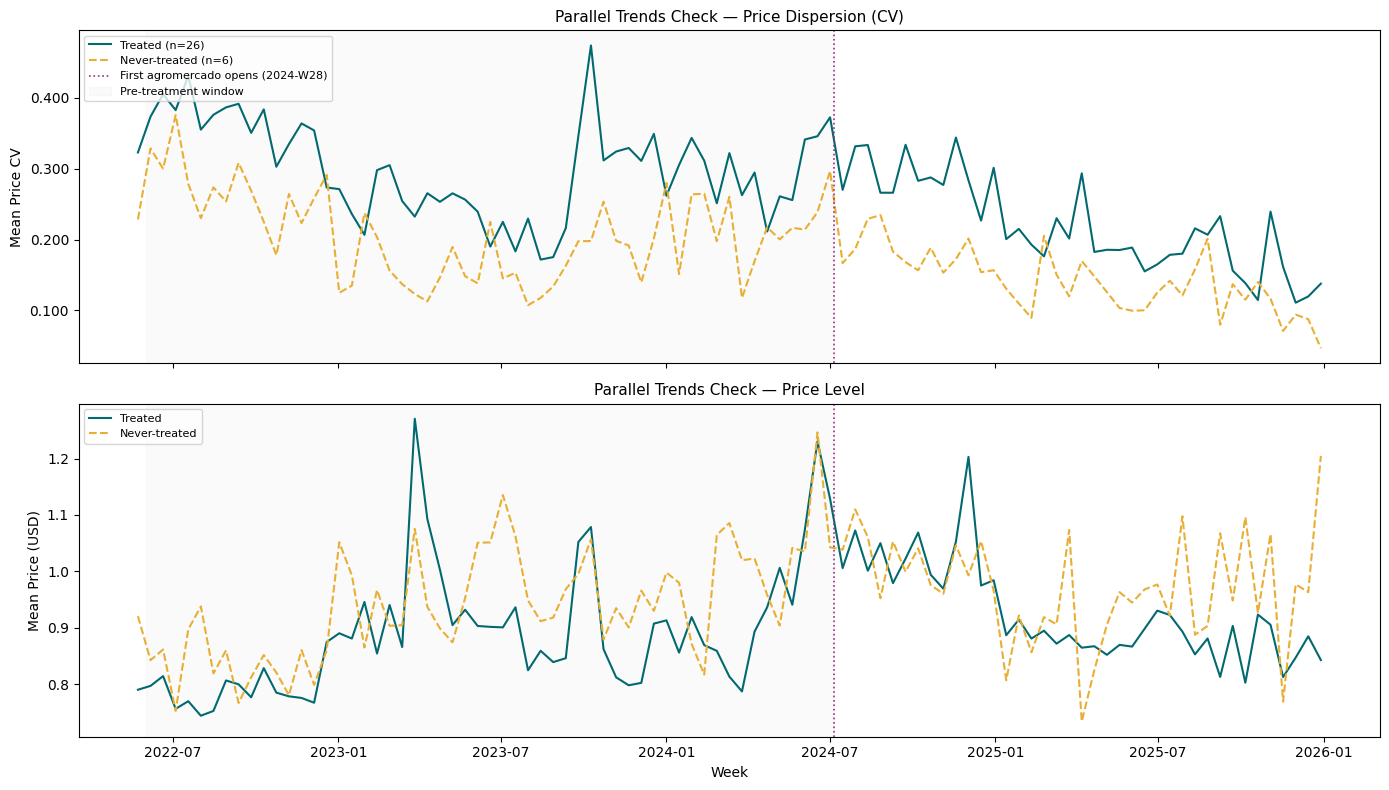

✅ Saved: parallel_trends_raw.png


In [35]:
# ── Load outcomes (already in memory as df_outcomes, or reload) ──
df = con.execute("""
    SELECT
        period_14d,
        period_14d                AS week_start,   -- alias for downstream pandas compatibility
        treated_5km,
        AVG(price_cv)             AS mean_cv,
        AVG(price_mean)           AS mean_price,
        COUNT(*)                  AS n_obs
    FROM panel_outcomes
    WHERE price_cv IS NOT NULL
    GROUP BY period_14d, treated_5km
    ORDER BY period_14d
""").df()

df['week_start'] = pd.to_datetime(df['week_start'])

treated   = df[df['treated_5km'] == 1]
control   = df[df['treated_5km'] == 0]

# ── Treatment onset line ──
TREAT_START = pd.Timestamp('2024-07-05')  # 2024-W28 Monday

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# ── Panel A: Price CV ──
ax = axes[0]
ax.plot(treated['week_start'],  treated['mean_cv'],
        color='#01696f', lw=1.5, label='Treated (n=26)')
ax.plot(control['week_start'],  control['mean_cv'],
        color='#e8af34', lw=1.5, linestyle='--', label='Never-treated (n=6)')
ax.axvline(TREAT_START, color='#a12c7b', lw=1.2,
           linestyle=':', label='First agromercado opens (2024-W28)')
ax.axvspan(pd.Timestamp('2022-06-01'), TREAT_START,
           alpha=0.04, color='grey', label='Pre-treatment window')
ax.set_ylabel('Mean Price CV', fontsize=10)
ax.set_title('Parallel Trends Check — Price Dispersion (CV)', fontsize=11)
ax.legend(fontsize=8, loc='upper left')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))

# ── Panel B: Price Level ──
ax2 = axes[1]
ax2.plot(treated['week_start'], treated['mean_price'],
         color='#01696f', lw=1.5, label='Treated')
ax2.plot(control['week_start'], control['mean_price'],
         color='#e8af34', lw=1.5, linestyle='--', label='Never-treated')
ax2.axvline(TREAT_START, color='#a12c7b', lw=1.2, linestyle=':')
ax2.axvspan(pd.Timestamp('2022-06-01'), TREAT_START,
            alpha=0.04, color='grey')
ax2.set_ylabel('Mean Price (USD)', fontsize=10)
ax2.set_title('Parallel Trends Check — Price Level', fontsize=11)
ax2.legend(fontsize=8, loc='upper left')
ax2.set_xlabel('Week', fontsize=10)

plt.tight_layout()
plt.savefig(f"{defens}/../figures/parallel_trends_raw.png",
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Saved: parallel_trends_raw.png")

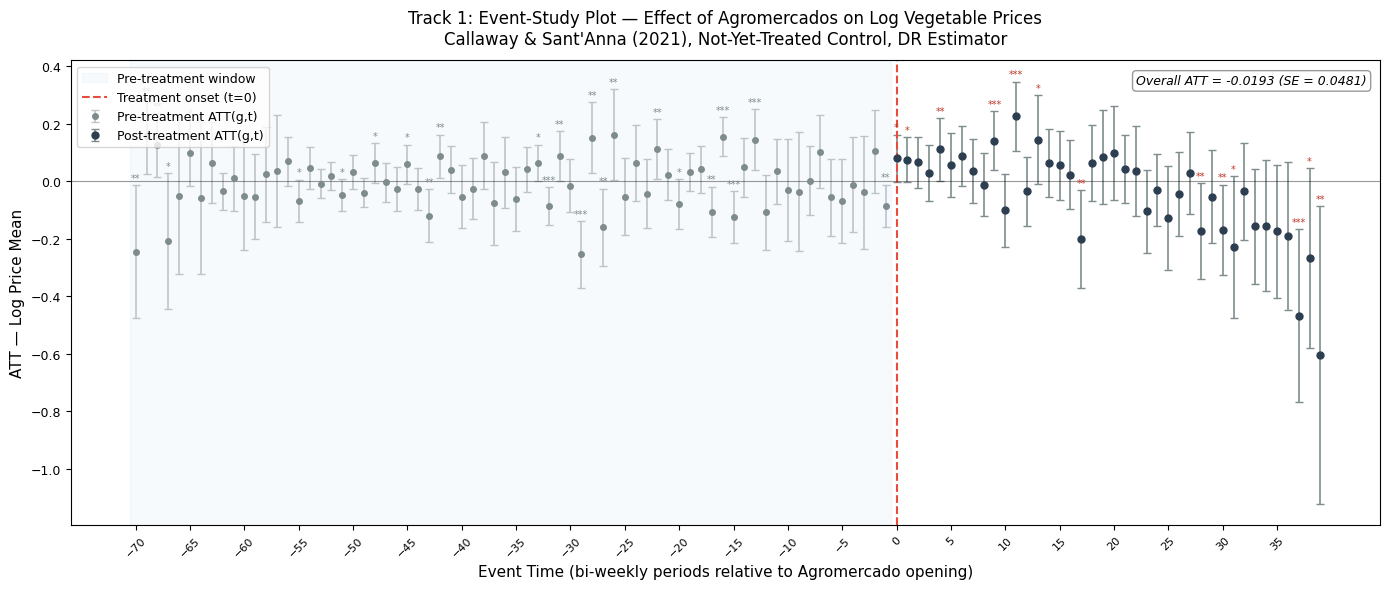

✅ Track 1 event-study plot saved.


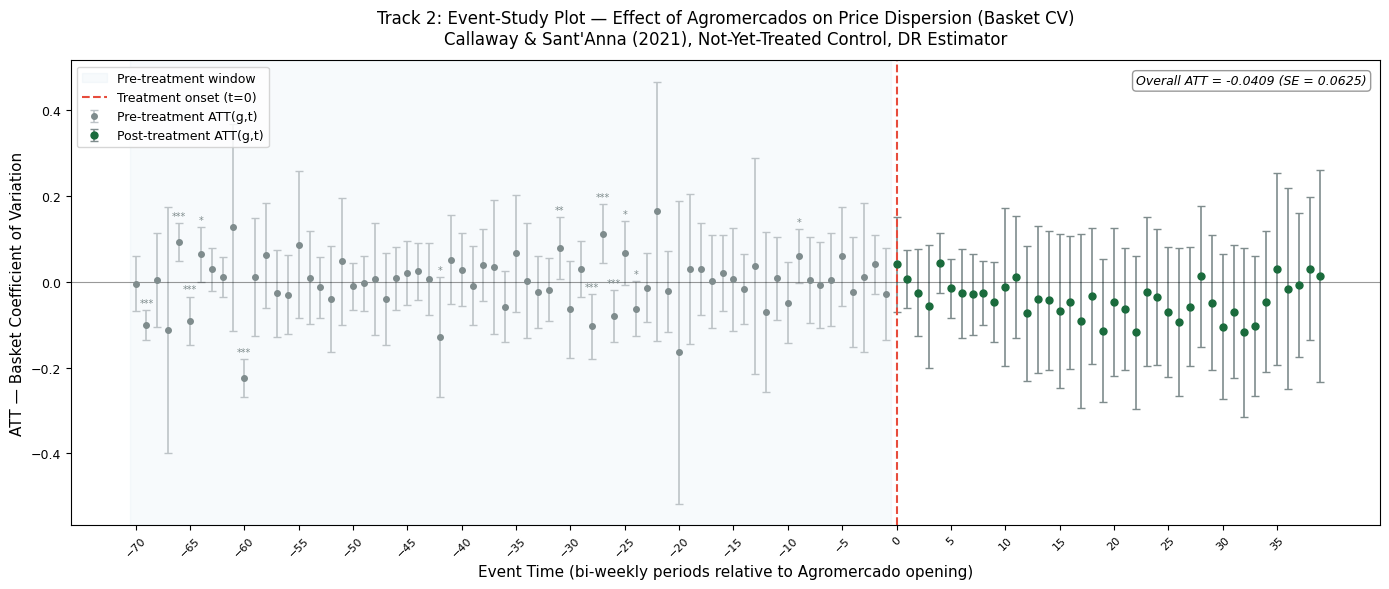

✅ Track 2 event-study plot saved.


In [36]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 15: EVENT-STUDY PLOTS — TRACK 1 & TRACK 2
# ══════════════════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import numpy as np

# ── Reload event-study DataFrames from CSV to avoid stale atte state ──────────
# aggte('simple') in Step 14 overwrites cs_track*_nyt.atte — never read
# cs_obj.atte after a second aggte() call; always use the saved files instead.
es_track1_nyt_df = pd.read_csv(f"{BASE}/es_track1_log_price_notyettreated.csv")
es_track2_nyt_df = pd.read_csv(f"{BASE}/es_track2_basket_cv_notyettreated.csv")


# ── STEP 15A: TRACK 1 — Log Price ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

df_plot = es_track1_nyt_df.copy()
pre  = df_plot[df_plot['event_time'] < 0]
post = df_plot[df_plot['event_time'] >= 0]

ax.errorbar(
    pre['event_time'], pre['att'],
    yerr=1.96 * pre['se'],
    fmt='o', color='#7f8c8d', ecolor='#bdc3c7',
    elinewidth=1.2, capsize=3, markersize=4, linewidth=0,
    label='Pre-treatment ATT(g,t)'
)
ax.errorbar(
    post['event_time'], post['att'],
    yerr=1.96 * post['se'],
    fmt='o', color='#2c3e50', ecolor='#7f8c8d',
    elinewidth=1.2, capsize=3, markersize=5, linewidth=0,
    label='Post-treatment ATT(g,t)'
)

# ── Highlight full pre-treatment window ───────────────────────────────────────
ax.axvspan(df_plot['event_time'].min() - 0.5, -0.5,
           alpha=0.04, color='steelblue', label='Pre-treatment window')

ax.axvline(x=0, color='#e74c3c', linewidth=1.5, linestyle='--', label='Treatment onset (t=0)')
ax.axhline(y=0, color='black',   linewidth=0.8, linestyle='-',  alpha=0.4)

for _, row in df_plot[df_plot['sig'].isin(['*', '**', '***'])].iterrows():
    ax.annotate(
        row['sig'],
        xy=(row['event_time'], row['att'] + 1.96 * row['se'] + 0.008),
        ha='center', va='bottom', fontsize=7,
        color='#c0392b' if row['event_time'] >= 0 else '#7f8c8d'
    )

ax.set_xlabel('Event Time (bi-weekly periods relative to Agromercado opening)', fontsize=11)
ax.set_ylabel('ATT — Log Price Mean', fontsize=11)
ax.set_title(
    'Track 1: Event-Study Plot — Effect of Agromercados on Log Vegetable Prices\n'
    'Callaway & Sant\'Anna (2021), Not-Yet-Treated Control, DR Estimator',
    fontsize=12, pad=12
)

xticks = np.arange(df_plot['event_time'].min(), df_plot['event_time'].max() + 1, 5)
ax.set_xticks(xticks)
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', labelsize=9)
ax.legend(fontsize=9, loc='upper left', framealpha=0.8)

# ── Overall ATT annotation — use scalars saved at estimation time ─────────────
ax.text(
    0.99, 0.97,
    f"Overall ATT = {overall_att_t1:.4f} (SE = {overall_se_t1:.4f})",
    transform=ax.transAxes, ha='right', va='top', fontsize=9, style='italic',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='grey', alpha=0.8)
)

plt.tight_layout()
plt.savefig(f"{figures}/track1_event_study_parallel_trends.png", dpi=300, bbox_inches='tight')
plt.show()
print("✅ Track 1 event-study plot saved.")


# ── STEP 15B: TRACK 2 — Basket CV ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

df_plot2 = es_track2_nyt_df.copy()
pre2  = df_plot2[df_plot2['event_time'] < 0]
post2 = df_plot2[df_plot2['event_time'] >= 0]

ax.errorbar(
    pre2['event_time'], pre2['att'],
    yerr=1.96 * pre2['se'],
    fmt='o', color='#7f8c8d', ecolor='#bdc3c7',
    elinewidth=1.2, capsize=3, markersize=4, linewidth=0,
    label='Pre-treatment ATT(g,t)'
)
ax.errorbar(
    post2['event_time'], post2['att'],
    yerr=1.96 * post2['se'],
    fmt='o', color='#1a6b3c', ecolor='#7f8c8d',
    elinewidth=1.2, capsize=3, markersize=5, linewidth=0,
    label='Post-treatment ATT(g,t)'
)

# ── Highlight full pre-treatment window ───────────────────────────────────────
ax.axvspan(df_plot2['event_time'].min() - 0.5, -0.5,
           alpha=0.04, color='steelblue', label='Pre-treatment window')

ax.axvline(x=0, color='#e74c3c', linewidth=1.5, linestyle='--', label='Treatment onset (t=0)')
ax.axhline(y=0, color='black',   linewidth=0.8, linestyle='-',  alpha=0.4)

for _, row in df_plot2[df_plot2['sig'].isin(['*', '**', '***'])].iterrows():
    ax.annotate(
        row['sig'],
        xy=(row['event_time'], row['att'] + 1.96 * row['se'] + 0.005),
        ha='center', va='bottom', fontsize=7,
        color='#c0392b' if row['event_time'] >= 0 else '#7f8c8d'
    )

ax.set_xlabel('Event Time (bi-weekly periods relative to Agromercado opening)', fontsize=11)
ax.set_ylabel('ATT — Basket Coefficient of Variation', fontsize=11)
ax.set_title(
    'Track 2: Event-Study Plot — Effect of Agromercados on Price Dispersion (Basket CV)\n'
    'Callaway & Sant\'Anna (2021), Not-Yet-Treated Control, DR Estimator',
    fontsize=12, pad=12
)

xticks = np.arange(df_plot2['event_time'].min(), df_plot2['event_time'].max() + 1, 5)
ax.set_xticks(xticks)
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', labelsize=9)
ax.legend(fontsize=9, loc='upper left', framealpha=0.8)

ax.text(
    0.99, 0.97,
    f"Overall ATT = {overall_att_t2:.4f} (SE = {overall_se_t2:.4f})",
    transform=ax.transAxes, ha='right', va='top', fontsize=9, style='italic',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='grey', alpha=0.8)
)

plt.tight_layout()
plt.savefig(f"{figures}/track2_event_study_parallel_trends.png", dpi=300, bbox_inches='tight')
plt.show()
print("✅ Track 2 event-study plot saved.")

In [ ]:
df_did = pd.read_parquet(f"{BASE}/panel_outcomes.parquet")
print(df_did.columns)
df_did.head()

In [ ]:
### interesting article -> opinions: https://cispes.org/article/bukele-claims-economic-prosperity-economist%E2%80%99s-data-shows-otherwise?language=es#:~:text=As%20international%20news%20outlets%20have,to%20meet%20the%20local%20demand.

#where to get CPI data: 
#https://www.bcr.gob.sv/documental/Inicio/busqueda/172

# Agromercado Prices Dataset:

In [ ]:
pgov_info_df = pd.read_csv( agro + "/agromercados_prices_info.csv" )
pgov_info_df.head()

In [ ]:
pgov_info_df['Publication_Date'] = pd.to_datetime(pgov_info_df['Publication_Date'])
pgov_info_df["Producto"].unique()

In [ ]:
array(['Ajo', 'Cebolla blanca', 'Chile verde', 'Banana', 'Limón',
       'Cebolla morada', 'Papa grande', 'Piña mediana', 'Plátano grande',
       'Tomate mediano', 'Repollo mediano', 'Pepino', 'Güisquil grande',
       'Lechuga grande', 'Zanahoria', 'Apio', 'Elote dulce amarillo',
       'Sandía grande', 'Piña grande', 'Brócoli pequeño', 'Arroz',
       'Frijol', 'Coliflor grande', 'Cebolla amarilla', 'Remolacha',
       'Naranja', 'Sandía pequeña', 'Repollo grande', 'Licha',
       'Rábano mediano', 'Berenjena grande', 'Lechuga pequeña',
       'Cebolla morada pequeña', 'Tomate grande', 'Plátano pequeño',
       'Güisquil mediano', 'Tomate pequeño', 'Ejote', 'Repollo pequeño',
       'Berenjena pequeña', 'Melocotón'], dtype=object)